# Poisson Regression vs. Exponential Fitter

## Two Lenses on the Same Underlying Process

These two models are not just related — they are mathematically dual descriptions of the same phenomenon.

A **Poisson process** with rate λ produces events randomly over time such that:
- The **count** of events in a time window of length $t$ follows **Poisson(λt)**
- The **waiting time** between consecutive events follows **Exponential(λ)**

The same λ governs both. So if you have event data, you can ask either question:

| Question | Model | Data shape |
|---|---|---|
| How many events happen per unit time (and how does a predictor affect that count)? | **Poisson Regression** | One row per observation period; response is a count |
| How long until the next event occurs? | **Exponential Fitter** | One row per subject/interval; response is a duration |

Your job: fit both models to two views of the same simulated dataset, and verify that they recover the same underlying rate.

In [1]:
!pip install lifelines

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 4.9 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.0/447.0 kB 4.4 MB/s eta 0:00:0031m62.1 MB/s eta 0:00:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4090 sha256=f200dfa99a096b393f1fe39f247ed1c704204404de89ee6be7d7f90f473b80d4
  Stored in directory: /Users/chelseatroy/Library/Caches/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from lifelines import ExponentialFitter, KaplanMeierFitter

plt.rc('figure', figsize=(10, 4))
np.random.seed(42)

## The Scenario: Customer Arrivals at a Service Counter

We're monitoring a service counter over 80 one-hour observation windows. The arrival rate depends on whether it is a **peak hour** (lunch rush, evening rush) or an **off-peak hour**.

The true model:

$$\log(\lambda) = \beta_0 + \beta_1 \cdot \text{is\_peak}$$

with $\beta_0 = \log(4)$ (off-peak rate: 4 customers/hour) and $\beta_1 = \log(2.5)$ (peak multiplier: 2.5×).

So:
- Off-peak: λ = 4 customers/hour → mean inter-arrival time = 15 minutes
- Peak: λ = 10 customers/hour → mean inter-arrival time = 6 minutes

In [3]:
# True parameters
b0_true = np.log(4.0)    # log(off-peak rate per hour)
b1_true = np.log(2.5)    # log(peak multiplier)
n_windows = 80

# Generate observation windows: randomly assigned peak/off-peak
is_peak = np.random.binomial(1, 0.4, size=n_windows)  # 40% peak hours
lam_per_hour = np.exp(b0_true + b1_true * is_peak)    # true rate for each window

# Poisson view: counts per window
counts = np.random.poisson(lam_per_hour)

df_poisson = pd.DataFrame({
    'window_id': range(n_windows),
    'is_peak': is_peak,
    'lam_true': lam_per_hour.round(3),
    'arrivals': counts
})

print('--- Poisson view: counts per hour ---')
print(f'Off-peak windows: {(is_peak==0).sum()}  |  Peak windows: {(is_peak==1).sum()}')
print(f'Mean arrivals (off-peak): {df_poisson[df_poisson.is_peak==0].arrivals.mean():.2f}  (true: 4.0)')
print(f'Mean arrivals (peak):     {df_poisson[df_poisson.is_peak==1].arrivals.mean():.2f}  (true: 10.0)')
df_poisson.head(8)

--- Poisson view: counts per hour ---
Off-peak windows: 51  |  Peak windows: 29
Mean arrivals (off-peak): 4.02  (true: 4.0)
Mean arrivals (peak):     9.69  (true: 10.0)


,window_id,is_peak,lam_true,arrivals
0,0,0,4.0,3
1,1,1,10.0,8
2,2,1,10.0,12
3,3,0,4.0,5
4,4,0,4.0,4
5,5,0,4.0,1
6,6,0,4.0,5
7,7,1,10.0,13


In [4]:
# Exponential view: simulate inter-arrival times from the same windows
# For each arrival within a window, the time until the *next* arrival ~ Exp(lam_per_minute)
# lam_per_minute = lam_per_hour / 60

# We generate inter-arrival times for each window until we fill the hour (60 min)
# Any interval still in progress at the window boundary is right-censored.

rows = []
for i, (peak, lam_h) in enumerate(zip(is_peak, lam_per_hour)):
    lam_m = lam_h / 60.0  # per-minute rate
    t = 0.0
    while True:
        gap = np.random.exponential(1.0 / lam_m)
        if t + gap > 60.0:
            # Censored: window closed before next arrival
            rows.append({'window_id': i, 'is_peak': peak,
                         'duration_min': round(60.0 - t, 2), 'event': 0})
            break
        t += gap
        rows.append({'window_id': i, 'is_peak': peak,
                     'duration_min': round(gap, 2), 'event': 1})

df_exp = pd.DataFrame(rows)

print('--- Exponential view: inter-arrival times ---')
print(f'{len(df_exp)} intervals total  |  '
      f'{df_exp.event.sum()} observed arrivals  |  '
      f'{(df_exp.event==0).sum()} censored (window closed)')
print(f'Mean inter-arrival (off-peak, observed): '
      f'{df_exp[(df_exp.is_peak==0)&(df_exp.event==1)].duration_min.mean():.2f} min  (true: 15.0)')
print(f'Mean inter-arrival (peak,     observed): '
      f'{df_exp[(df_exp.is_peak==1)&(df_exp.event==1)].duration_min.mean():.2f} min  (true: 6.0)')
df_exp.head(10)

--- Exponential view: inter-arrival times ---
590 intervals total  |  510 observed arrivals  |  80 censored (window closed)
Mean inter-arrival (off-peak, observed): 11.00 min  (true: 15.0)
Mean inter-arrival (peak,     observed): 5.00 min  (true: 6.0)


,window_id,is_peak,duration_min,event
0,0,0,14.99,1
1,0,0,8.93,1
2,0,0,5.21,1
3,0,0,5.98,1
4,0,0,16.74,1
5,0,0,8.16,0
6,1,1,9.41,1
7,1,1,9.35,1
8,1,1,0.57,1
9,1,1,4.09,1


---
## Model 1 — Poisson Regression

We fit a Poisson GLM with a log link:

$$\log(\hat{\lambda}_i) = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{is\_peak}_i$$

The exponentiated coefficients have a natural interpretation: $e^{\hat{\beta}_0}$ is the estimated off-peak rate, and $e^{\hat{\beta}_1}$ is the multiplicative factor for peak hours.

In [5]:
pois_model = smf.glm(
    'arrivals ~ is_peak',
    data=df_poisson,
    family=sm.families.Poisson()
).fit()

print(pois_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               arrivals   No. Observations:                   80
Model:                            GLM   Df Residuals:                       78
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -180.34
Date:                Mon, 13 Apr 2026   Deviance:                       83.154
Time:                        20:06:04   Pearson chi2:                     77.5
No. Iterations:                     4   Pseudo R-squ. (CS):             0.6875
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3912      0.070     19.919      0.0

In [6]:
b0_hat = pois_model.params['Intercept']
b1_hat = pois_model.params['is_peak']

lam_offpeak_poisson = np.exp(b0_hat)
lam_peak_poisson    = np.exp(b0_hat + b1_hat)
peak_multiplier     = np.exp(b1_hat)

print('=== Poisson Regression Results ===')
print(f'β₀ = {b0_hat:.4f}  (true: {b0_true:.4f})')
print(f'β₁ = {b1_hat:.4f}  (true: {b1_true:.4f})')
print()
print(f'Estimated off-peak rate:  λ̂ = exp(β₀)      = {lam_offpeak_poisson:.3f} customers/hour  (true: 4.0)')
print(f'Estimated peak rate:      λ̂ = exp(β₀ + β₁) = {lam_peak_poisson:.3f} customers/hour  (true: 10.0)')
print(f'Peak multiplier:          exp(β₁)            = {peak_multiplier:.3f}×                   (true: 2.5×)')

=== Poisson Regression Results ===
β₀ = 1.3912  (true: 1.3863)
β₁ = 0.8799  (true: 0.9163)

Estimated off-peak rate:  λ̂ = exp(β₀)      = 4.020 customers/hour  (true: 4.0)
Estimated peak rate:      λ̂ = exp(β₀ + β₁) = 9.690 customers/hour  (true: 10.0)
Peak multiplier:          exp(β₁)            = 2.411×                   (true: 2.5×)


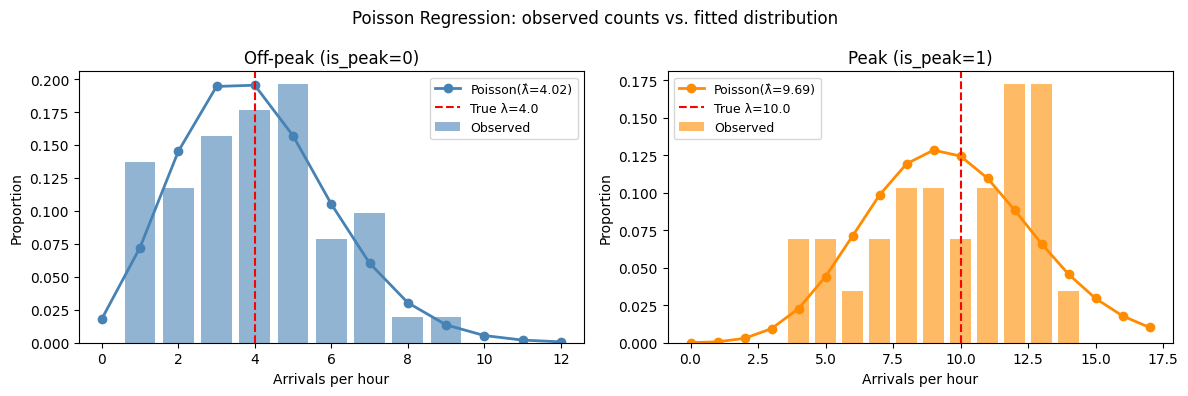

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, peak, label, col, lam_true, lam_hat in zip(
    axes, [0, 1],
    ['Off-peak (is_peak=0)', 'Peak (is_peak=1)'],
    ['steelblue', 'darkorange'],
    [4.0, 10.0],
    [lam_offpeak_poisson, lam_peak_poisson]
):
    subset = df_poisson[df_poisson.is_peak == peak]['arrivals']
    x_vals = np.arange(0, subset.max() + 4)
    from scipy.stats import poisson
    ax.bar(subset.value_counts().sort_index().index,
           subset.value_counts().sort_index().values / len(subset),
           color=col, alpha=0.6, label='Observed')
    ax.plot(x_vals, poisson.pmf(x_vals, lam_hat), 'o-', color=col,
            linewidth=2, label=f'Poisson(λ̂={lam_hat:.2f})')
    ax.axvline(lam_true, color='red', linestyle='--', linewidth=1.5,
               label=f'True λ={lam_true}')
    ax.set_xlabel('Arrivals per hour')
    ax.set_ylabel('Proportion')
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.suptitle('Poisson Regression: observed counts vs. fitted distribution', fontsize=12)
plt.tight_layout()
plt.show()

---
## Model 2 — Exponential Fitter

We now use the inter-arrival time view. Each row in `df_exp` is one interval, with a duration and an event indicator (1 = arrival observed, 0 = window closed before arrival — right-censored).

The `ExponentialFitter` estimates one $\hat{\lambda}$ for all observations (or stratified by group). The mean survival time is $1/\hat{\lambda}$.

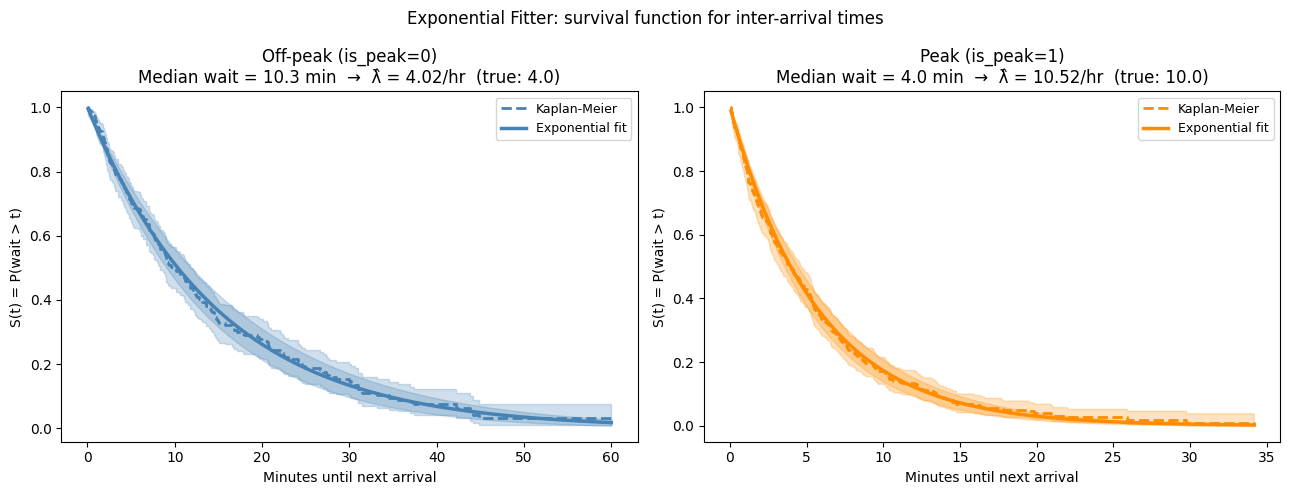

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lam_exp = {}

for ax, peak, label, col, lam_true in zip(
    axes, [0, 1],
    ['Off-peak (is_peak=0)', 'Peak (is_peak=1)'],
    ['steelblue', 'darkorange'],
    [4.0, 10.0]
):
    subset = df_exp[df_exp.is_peak == peak]

    # Kaplan-Meier (non-parametric)
    kmf = KaplanMeierFitter()
    kmf.fit(subset['duration_min'], event_observed=subset['event'], label='Kaplan-Meier')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=col, linestyle='--', linewidth=2)

    # Exponential parametric fit
    ef = ExponentialFitter()
    ef.fit(subset['duration_min'], event_observed=subset['event'], label='Exponential fit')
    ef.plot_survival_function(ax=ax, ci_show=True, color=col, linewidth=2.5)

    lam_per_min = 1.0 / ef.median_survival_time_ * np.log(2)  # recover lambda from median
    # More directly: lambda = 1/mean_survival_time for exponential
    lam_hat_per_hr = 60.0 / ef.median_survival_time_ * np.log(2)
    lam_exp[peak] = lam_hat_per_hr

    ax.set_xlabel('Minutes until next arrival')
    ax.set_ylabel('S(t) = P(wait > t)')
    ax.set_title(f'{label}\nMedian wait = {ef.median_survival_time_:.1f} min'
                 f'  →  λ̂ = {lam_hat_per_hr:.2f}/hr  (true: {lam_true})')
    ax.legend(fontsize=9)

plt.suptitle('Exponential Fitter: survival function for inter-arrival times', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Print survival model summaries
for peak, label in [(0, 'Off-peak'), (1, 'Peak')]:
    subset = df_exp[df_exp.is_peak == peak]
    ef = ExponentialFitter()
    ef.fit(subset['duration_min'], event_observed=subset['event'])
    print(f'=== {label} ===')
    ef.print_summary()
    print()

=== Off-peak ===


<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 256 total observations, 51 right-censored observations>
   number of observations = 256
number of events observed = 205
           log-likelihood = -759.14
               hypothesis = lambda_ != 0

---
         coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 14.93      1.04           12.88           16.97

         cmp to     z      p  -log2(p)
lambda_    0.00 14.32 <0.005    152.05
---
AIC = 1520.29


=== Peak ===


<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 334 total observations, 29 right-censored observations>
   number of observations = 334
number of events observed = 305
           log-likelihood = -836.11
               hypothesis = lambda_ != 0

---
         coef  se(coef)  coef lower 95%  coef upper 95%
lambda_  5.71      0.33            5.06            6.35

         cmp to     z      p  -log2(p)
lambda_    0.00 17.46 <0.005    224.47
---
AIC = 1674.22

---
## The Comparison: Does the Same λ Emerge from Both Models?

In [10]:
comparison = pd.DataFrame({
    'Condition': ['Off-peak', 'Peak'],
    'True λ (per hour)': [4.0, 10.0],
    'Poisson Regression λ̂': [round(lam_offpeak_poisson, 3), round(lam_peak_poisson, 3)],
    'ExponentialFitter λ̂': [round(lam_exp[0], 3), round(lam_exp[1], 3)],
}).set_index('Condition')

comparison

,True λ (per hour),Poisson Regression λ̂,ExponentialFitter λ̂
Condition,,,
Off-peak,4.0,4.02,4.020
Peak,10.0,9.69,10.517


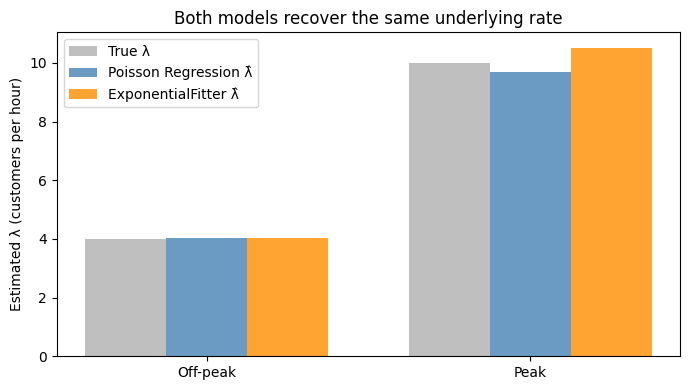

In [11]:
# Visualize agreement
fig, ax = plt.subplots(figsize=(7, 4))
x = np.array([0, 1])
width = 0.25

bars_true  = ax.bar(x - width, [4.0, 10.0], width, label='True λ', color='gray', alpha=0.5)
bars_pois  = ax.bar(x,          [lam_offpeak_poisson, lam_peak_poisson], width,
                    label='Poisson Regression λ̂', color='steelblue', alpha=0.8)
bars_exp   = ax.bar(x + width,  [lam_exp[0], lam_exp[1]], width,
                    label='ExponentialFitter λ̂', color='darkorange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['Off-peak', 'Peak'])
ax.set_ylabel('Estimated λ (customers per hour)')
ax.set_title('Both models recover the same underlying rate')
ax.legend()
plt.tight_layout()
plt.show()

---
## Discussion Questions

1. **The same λ**: Both models should recover rates close to the true values of 4 and 10 customers per hour. Do they agree with each other? Which model's estimate is closer to the truth? Is that consistent across both conditions?

2. **What censoring costs**: The exponential fitter handles right-censored observations (windows that closed before the next arrival). What would happen to the estimated λ if you simply **dropped** censored rows instead of including them? Try it: filter `df_exp` to `event==1` only, refit, and compare the result.

3. **Different questions, same λ**: The Poisson model answers "how many events per hour?" while the exponential model answers "how long until the next event?" These feel like different questions. Explain in your own words why they must give consistent λ estimates.

4. **The constant hazard assumption**: The exponential distribution assumes a *constant* hazard rate — the event is equally likely at every moment, regardless of how long you've been waiting (this is the memoryless property we discussed in our last session). Is that realistic for customer arrivals? What distribution might you use if you thought early arrivals were more likely, or if you believed arrivals "clustered" (someone arriving makes another arrival more likely)?

5. **Kaplan-Meier vs. parametric**: Compare the KM step function and the parametric exponential curve on the plots. In either condition, is there systematic departure from the exponential shape? What does it tell you about the quality of the exponential assumption?

6. **Extension**: Change the true model to have a *non-constant* rate (e.g., rate doubles after minute 30). Re-simulate. Does Poisson regression still work? Does the exponential fitter? What would you use instead for the survival model? (Hint: `WeibullFitter` from lifelines allows the hazard to increase or decrease with time.)